<a href="https://colab.research.google.com/github/KThakshila/Ai-model-/blob/main/image_clasification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [18]:
#import
import tensorflow as tf #colab main librari
from tensorflow import keras #model build with Api
from tensorflow.keras.preprocessing.image import ImageDataGenerator #image process
import numpy as np #numarical data handaling
import matplotlib.pyplot as plt # float image and  dsiplay

In [19]:
#define drive path
train_dir = '/content/drive/MyDrive/AI_Project/AI_Fruit_Classifier-20260725T175120Z-1-001/AI_Fruit_Classifier/train'

In [20]:
# moddel change(1-255px)
train_datagen = ImageDataGenerator(rescale=1./255)

In [6]:
#load image
train_generator = train_datagen.flow_from_directory(
        train_dir,
        target_size=(150, 150),
        batch_size=4,
        class_mode='binary') # jathi gana 2 k nisa

Found 20 images belonging to 2 classes.


In [23]:
model = keras.Sequential([

    keras.layers.Conv2D(16, (3,3), activation='relu', input_shape=(150, 150, 3)),
    keras.layers.MaxPooling2D(2,2),

    keras.layers.Conv2D(32, (3,3), activation='relu'),
    keras.layers.MaxPooling2D(2,2),

    keras.layers.Flatten(),

    keras.layers.Dense(512, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')


]) # 0 - aplle & 1 - mango

In [31]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [33]:
#train
history = model.fit(train_generator, epochs=10)

Epoch 1/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 1.0000 - loss: 2.4081e-04
Epoch 2/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 1.0000 - loss: 1.8123e-04
Epoch 3/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 1.0000 - loss: 1.1054e-04
Epoch 4/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 1.0000 - loss: 8.4260e-05
Epoch 5/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 1.0000 - loss: 6.9007e-05
Epoch 6/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 1.0000 - loss: 5.3525e-05
Epoch 7/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 1.0000 - loss: 4.5477e-05
Epoch 8/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 1.0000 - loss: 3.8120e-05
Epoch 9/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 1.0000 - loss: 3.3383e-05
Epoch 10/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 1.0000 - loss: 2.8167e-05


In [34]:
#test
test_apple_path = '/content/drive/My Drive/AI_Project/AI_Fruit_Classifier-20260725T175120Z-1-001/AI_Fruit_Classifier/test/test_apple.jpg'
test_mango_path = '/content/drive/My Drive/AI_Project/AI_Fruit_Classifier-20260725T175120Z-1-001/AI_Fruit_Classifier/test/test_mango.jpg'

In [35]:
class_labels = list(train_generator.class_indices.keys())

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 289ms/step


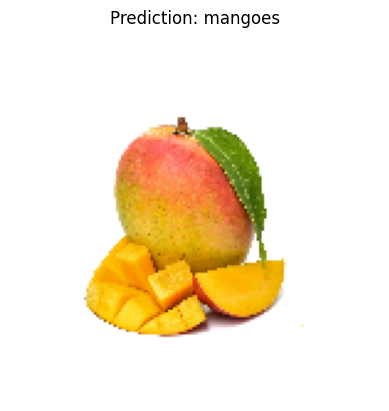

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


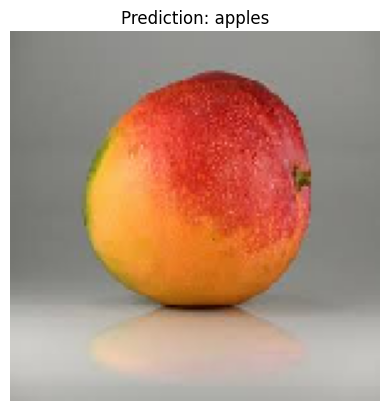

In [36]:
def predict_image(image_path):
  img = keras.preprocessing.image.load_img(image_path, target_size=(150, 150))
  img_array = keras.preprocessing.image.img_to_array(img)
  img_array = np.expand_dims(img_array, axis=0)
  img_array /= 255.0
  prediction = model.predict(img_array)

  plt.imshow(img)
  plt.axis('off')

  if prediction[0] >= 0.5:
    predicted_class = class_labels[1]
  else:
    predicted_class = class_labels[0]

  plt.title(f"Prediction: {predicted_class}")
  plt.show()

predict_image(test_apple_path)
predict_image(test_mango_path)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


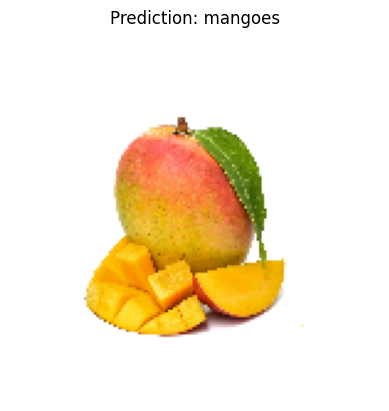

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


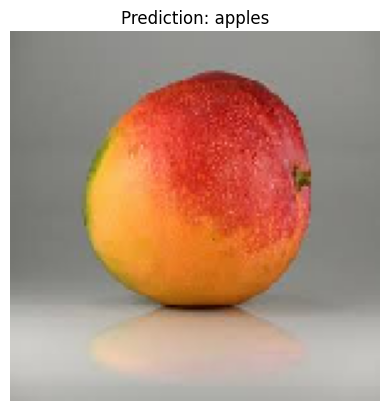

In [37]:
def predict_image(image_path):
  img = keras.preprocessing.image.load_img(image_path, target_size=(150, 150))
  img_array = keras.preprocessing.image.img_to_array(img)
  img_array = np.expand_dims(img_array, axis=0)
  img_array /= 255.0
  prediction = model.predict(img_array)

  plt.imshow(img)
  plt.axis('off')

  if prediction[0] >= 0.5:
    predicted_class = class_labels[1]
  else:
    predicted_class = class_labels[0]

  plt.title(f"Prediction: {predicted_class}")
  plt.show()

predict_image(test_apple_path)
predict_image(test_mango_path)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


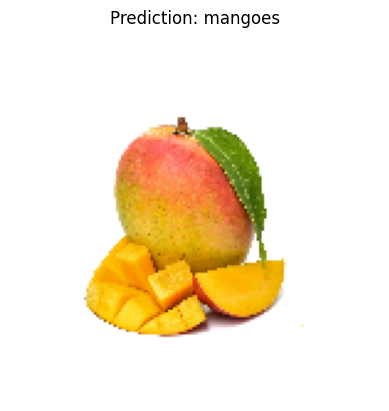

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


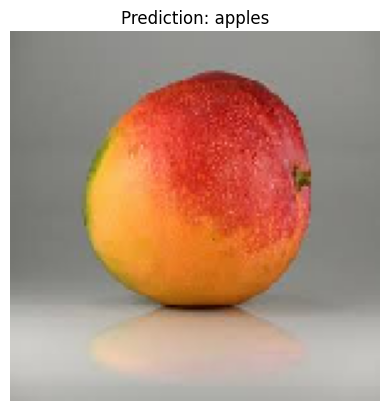

In [38]:
def predict_image(image_path):
  img = keras.preprocessing.image.load_img(image_path, target_size=(150, 150))
  img_array = keras.preprocessing.image.img_to_array(img)
  img_array = np.expand_dims(img_array, axis=0)
  img_array /= 255.0
  prediction = model.predict(img_array)

  plt.imshow(img)
  plt.axis('off')

  if prediction[0] >= 0.5:
    predicted_class = class_labels[1]
  else:
    predicted_class = class_labels[0]

  plt.title(f"Prediction: {predicted_class}")
  plt.show()

predict_image(test_apple_path)
predict_image(test_mango_path)

In [ ]:
def predict_image(image_path):
  img = keras.preprocessing.image.load_img(image_path, target_size=(150, 150))
  img_array = keras.preprocessing.image.img_to_array(img)
  img_array = np.expand_dims(img_array, axis=0)
  img_array /= 255.0
  prediction = model.predict(img_array)

  plt.imshow(img)
  plt.axis('off')

  if prediction[0] >= 0.5:
    predicted_class = class_labels[1]
  else:
    predicted_class = class_labels[0]

  plt.title(f"Prediction: {predicted_class}")
  plt.show()

predict_image(test_apple_path)
predict_image(test_mango_path)